# Silicon project: EPM band structure, dopants, and junction I-V

This notebook merges the EPM band-structure workflow with temperature- and doping-dependent junction physics. It keeps the analysis cohesive: EPM sets the band structure context, dopants affect the gap and Fermi level, and the diode model uses temperature-dependent carrier statistics.


## Workflow (step-by-step)
- Define the silicon EPM model and k-path through the Brillouin zone.
- Solve EPM band structure with dopant perturbations and gap narrowing.
- Compute Fermi statistics and dopant sweeps for gap + SQ efficiency.
- Simulate SQ I-V and power curves from the corrected gap.
- Model a step-junction diode with temperature-dependent statistics.
- Save figures and results to a configuration-specific results folder.


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

from quantsim.bz import BrillouinZonePath
from quantsim.diode import (
    built_in_potential_v,
    depletion_width_cm,
    diode_saturation_current_density_a_per_cm2,
    shockley_diode_current_density_a_per_cm2,
)
from quantsim.doping import DopantCase, band_gap_narrowing_si
from quantsim.epm import (
    DopantPerturbation,
    EmpiricalPseudopotential,
    solve_epm_band_structure,
)
from quantsim.fermi import fermi_dirac, fermi_level_si
from quantsim.lattice import Lattice
from quantsim.materials import silicon
from quantsim.plotting import plot_bands, plot_kpath, plot_reciprocal_lattice
from quantsim.solar import shockley_queisser_limit
from quantsim.stats import (
    effective_density_of_states_cm3,
    fermi_level_nondegenerate_ev,
    intrinsic_concentration_cm3,
    mobility_power_law,
    thermal_voltage_v,
    varshni_gap_ev,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


/home/ubuntu/projects/simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulation config
Edit these values first. All outputs are tagged with this run config.


In [2]:
# Simulation config (edit here)
RUN = {
    "name": "silicon_epm_diode",
    "results_root": "results_silicon_epm_diode",
    "tag": "baseline",
}

EPM = {
    "temperature_k": 300.0,
    "n_doping_cm3": 1e19,
    "p_doping_cm3": 1e16,
    "g_cut_shell": 11.5,
    "n_bands": 10,
    "points_per_segment": 40,
    "target_gap_ev": 1.12,
    "valence_band_index": 4,
}

DOPANT_PERTURBATIONS = {
    "P": {3: -0.05, 8: 0.01, 11: 0.01},
    "B": {3: -0.04, 8: 0.01, 11: 0.01},
}

SWEEP = {
    "dopant_cm3": np.logspace(16, 20, 9),
    "points_per_segment": 24,
}

DIODE = {
    "n_side_cm3": 5e16,
    "p_side_cm3": 2e16,
    "temperature_range_k": (250.0, 450.0, 161),
    "marker_t_k": 300.0,
    "lifetimes_s": {"n": 2e-6, "p": 1e-6},
    "iv_plot_temps_k": [280.0, 300.0, 360.0],
    "voltages_v": np.linspace(0.0, 0.85, 300),
}


In [3]:
def slugify(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace(":", "")
        .replace("+", "")
    )


def make_results_dir(root_name, run_name, tag):
    root = Path(root_name)
    root.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    config_slug = slugify(f"{run_name}_{tag}")
    out_dir = root / f"{config_slug}_{stamp}"
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def save_fig(fig, path, dpi=220):
    fig.savefig(path, dpi=dpi, bbox_inches="tight")


def _serialize(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.floating, np.integer)):
        return value.item()
    if isinstance(value, dict):
        return {k: _serialize(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_serialize(v) for v in value]
    return value


def write_run_config(out_dir, config, filename="run_config.json"):
    path = Path(out_dir) / filename
    with path.open("w", encoding="utf-8") as handle:
        json.dump(_serialize(config), handle, indent=2)


def print_table(headers, rows, title=None):
    if title:
        print(title)
    widths = [len(h) for h in headers]
    for row in rows:
        widths = [max(w, len(str(val))) for w, val in zip(widths, row)]
    header_line = " | ".join(h.ljust(w) for h, w in zip(headers, widths))
    sep_line = "-+-".join("-" * w for w in widths)
    print(header_line)
    print(sep_line)
    for row in rows:
        print(" | ".join(str(val).ljust(w) for val, w in zip(row, widths)))
    print()


## EPM band structure and dopant perturbations
We compute the silicon band structure along a high-symmetry k-path, including dopant perturbations and band-gap narrowing. This provides a consistent band-edge reference for the rest of the project.


In [4]:
model = EmpiricalPseudopotential.silicon()
lattice = Lattice.fcc(a=model.lattice_constant_m)
path = BrillouinZonePath.for_lattice("fcc")

temperature_k = EPM["temperature_k"]
n_doping = EPM["n_doping_cm3"]
p_doping = EPM["p_doping_cm3"]

# Plane-wave cutoff chosen to include |G|^2 shells for Si.
g_cut = (2.0 * np.pi / model.lattice_constant_m) * np.sqrt(EPM["g_cut_shell"])

run_tag = f"T{temperature_k:.0f}K_n{n_doping:.1e}_p{p_doping:.1e}_{RUN['tag']}"
results_dir = make_results_dir(RUN["results_root"], RUN["name"], run_tag)

write_run_config(
    results_dir,
    {
        "run": RUN,
        "epm": EPM,
        "dopant_perturbations": DOPANT_PERTURBATIONS,
        "sweep": SWEEP,
        "diode": DIODE,
    },
)


In [5]:
# fig, ax = plt.subplots(figsize=(6.2, 3))
# plot_kpath(lattice, path, points_per_segment=30, ax=ax)

# fig = plt.figure(figsize=(6.0, 5.0))
# ax = fig.add_subplot(111, projection="3d")
# plot_reciprocal_lattice(lattice, repeats=1, ax=ax)

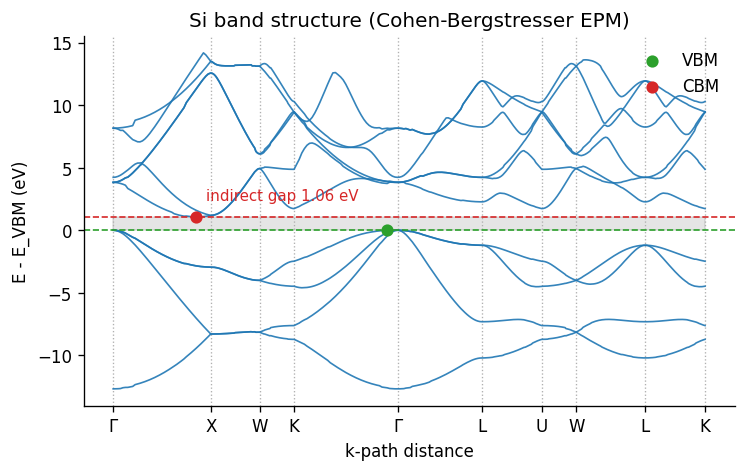

EPM summary
Metric          | Value 
----------------+-------
Gap (eV)        | 1.064 
VBM (eV)        | 10.586
CBM (eV)        | 11.650
Direct gap (eV) | 3.469 
Direct?         | False 



In [6]:
dopant_gap_shift = -band_gap_narrowing_si(n_doping, p_doping, temperature_k=temperature_k)

dopants = [
    DopantPerturbation(
        element="P",
        concentration_cm3=n_doping,
        delta_vs_form_factors_ev=DOPANT_PERTURBATIONS["P"],
    ),
    DopantPerturbation(
        element="B",
        concentration_cm3=p_doping,
        delta_vs_form_factors_ev=DOPANT_PERTURBATIONS["B"],
    ),
]

result = solve_epm_band_structure(
    lattice=lattice,
    model=model,
    path=path,
    g_cut=g_cut,
    n_bands=EPM["n_bands"],
    points_per_segment=EPM["points_per_segment"],
    dopants=dopants,
    valence_band_index=EPM["valence_band_index"],
    target_gap_ev=EPM["target_gap_ev"],
    dopant_gap_shift_ev=dopant_gap_shift,
)

# Reference energies to the valence-band maximum (E_VBM = 0), the usual convention.
ax = plot_bands(
    result.distances,
    result.energies_ev - result.vbm_ev,
    result.ticks,
    result.labels,
    0.0,
    result.gap_ev,
    result.vbm_k_index,
    result.cbm_k_index,
)
ax.set_ylabel("E - E_VBM (eV)")
ax.set_title("Si band structure (Cohen-Bergstresser EPM)")
ax.annotate(
    f"indirect gap {result.gap_ev:.2f} eV",
    xy=(result.distances[result.cbm_k_index], result.gap_ev),
    xytext=(6, 10),
    textcoords="offset points",
    fontsize=9,
    color="#d62728",
)
plt.show()
save_fig(ax.figure, results_dir / "si_epm_band_structure.png")

print_table(
    ["Metric", "Value"],
    [
        ("Gap (eV)", f"{result.gap_ev:.3f}"),
        ("VBM (eV)", f"{result.vbm_ev:.3f}"),
        ("CBM (eV)", f"{result.cbm_ev:.3f}"),
        ("Direct gap (eV)", f"{result.direct_gap_ev:.3f}"),
        ("Direct?", str(result.is_direct_gap)),
    ],
    title="EPM summary",
)


## Carrier statistics and SQ trends
We use the EPM gap to set the Fermi level and quantify how dopant concentration shifts the gap and SQ efficiency.


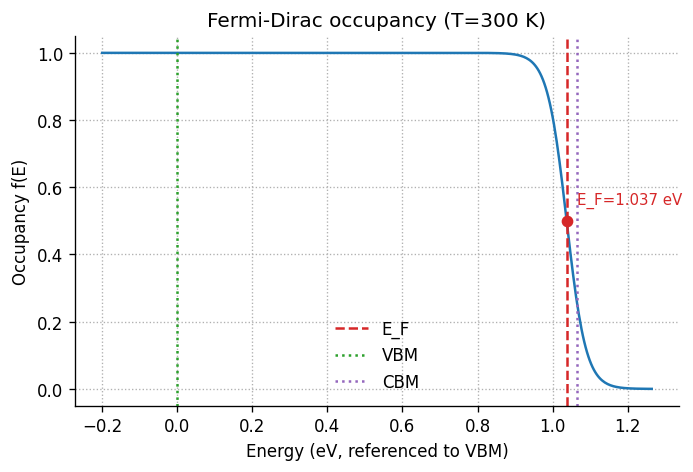

Fermi level summary
Metric                     | Value
---------------------------+------
Fermi level above VBM (eV) | 1.037



In [7]:
ef = fermi_level_si(n_doping, p_doping, band_gap_ev=result.gap_ev, temperature_k=temperature_k)
energies = np.linspace(-0.2, result.gap_ev + 0.2, 400)
occupancy = fermi_dirac(energies, ef, temperature_k)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(energies, occupancy, color="#1f77b4")
ax.axvline(ef, color="#d62728", linestyle="--", label="E_F")
ax.axvline(0.0, color="#2ca02c", linestyle=":", label="VBM")
ax.axvline(result.gap_ev, color="#9467bd", linestyle=":", label="CBM")
ax.scatter([ef], [0.5], color="#d62728", zorder=5)
ax.annotate(
    f"E_F={ef:.3f} eV",
    xy=(ef, 0.5),
    xytext=(6, 10),
    textcoords="offset points",
    fontsize=9,
    color="#d62728",
)
ax.set_xlabel("Energy (eV, referenced to VBM)")
ax.set_ylabel("Occupancy f(E)")
ax.set_title(f"Fermi-Dirac occupancy (T={temperature_k:.0f} K)")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_fermi_dirac.png")

print_table(
    ["Metric", "Value"],
    [("Fermi level above VBM (eV)", f"{ef:.3f}")],
    title="Fermi level summary",
)


Dopant sweep:   0%|          | 0/9 [00:00<?, ?conc/s]

Dopant sweep:  11%|█         | 1/9 [00:00<00:01,  6.53conc/s]

Dopant sweep:  22%|██▏       | 2/9 [00:00<00:01,  6.57conc/s]

Dopant sweep:  33%|███▎      | 3/9 [00:00<00:00,  6.70conc/s]

Dopant sweep:  44%|████▍     | 4/9 [00:00<00:00,  6.66conc/s]

...

Dopant sweep:  67%|██████▋   | 6/9 [00:00<00:00,  5.65conc/s]

Dopant sweep:  78%|███████▊  | 7/9 [00:01<00:00,  5.83conc/s]

Dopant sweep:  89%|████████▉ | 8/9 [00:01<00:00,  5.95conc/s]

Dopant sweep: 100%|██████████| 9/9 [00:01<00:00,  6.19conc/s]

Dopant sweep: 100%|██████████| 9/9 [00:01<00:00,  6.13conc/s]

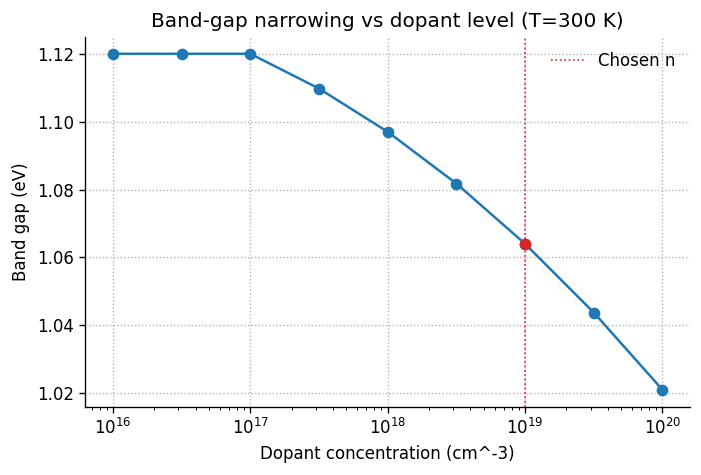

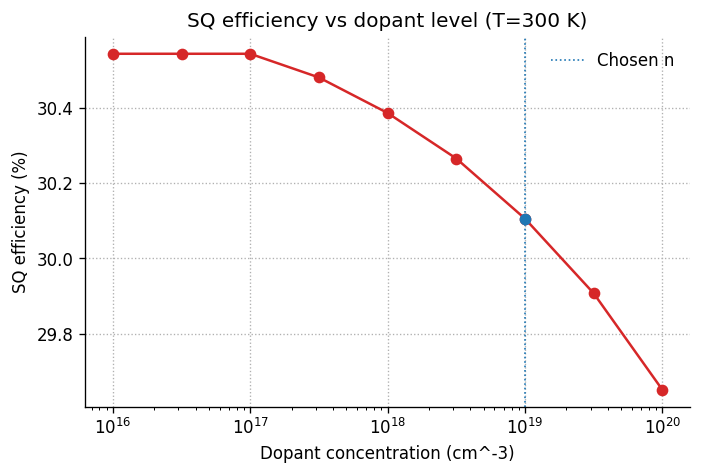

In [8]:
concentrations = SWEEP["dopant_cm3"]
gaps = []
efficiencies = []
for conc in tqdm(concentrations, desc="Dopant sweep", unit="conc"):
    shift = -band_gap_narrowing_si(conc, 0.0, temperature_k=temperature_k)
    res = solve_epm_band_structure(
        lattice=lattice,
        model=model,
        path=path,
        g_cut=g_cut,
        n_bands=EPM["n_bands"],
        points_per_segment=SWEEP["points_per_segment"],
        dopants=[
            DopantPerturbation(
                element="P",
                concentration_cm3=conc,
                delta_vs_form_factors_ev=DOPANT_PERTURBATIONS["P"],
            )
        ],
        valence_band_index=EPM["valence_band_index"],
        target_gap_ev=EPM["target_gap_ev"],
        dopant_gap_shift_ev=shift,
    )
    gaps.append(res.gap_ev)
    efficiencies.append(
        shockley_queisser_limit(res.gap_ev, cell_temperature_k=temperature_k).efficiency
    )

gaps = np.array(gaps)
efficiencies = np.array(efficiencies)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(concentrations, gaps, marker="o", color="#1f77b4")
ax.scatter([n_doping], [np.interp(n_doping, concentrations, gaps)], color="#d62728", zorder=5)
ax.axvline(n_doping, color="#d62728", linestyle=":", linewidth=1.0, label="Chosen n")
ax.set_xlabel("Dopant concentration (cm^-3)")
ax.set_ylabel("Band gap (eV)")
ax.set_title(f"Band-gap narrowing vs dopant level (T={temperature_k:.0f} K)")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_gap_vs_doping.png")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogx(concentrations, efficiencies * 100.0, marker="o", color="#d62728")
ax.scatter(
    [n_doping],
    [np.interp(n_doping, concentrations, efficiencies) * 100.0],
    color="#1f77b4",
    zorder=5,
)
ax.axvline(n_doping, color="#1f77b4", linestyle=":", linewidth=1.0, label="Chosen n")
ax.set_xlabel("Dopant concentration (cm^-3)")
ax.set_ylabel("SQ efficiency (%)")
ax.set_title(f"SQ efficiency vs dopant level (T={temperature_k:.0f} K)")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_sq_efficiency_vs_doping.png")


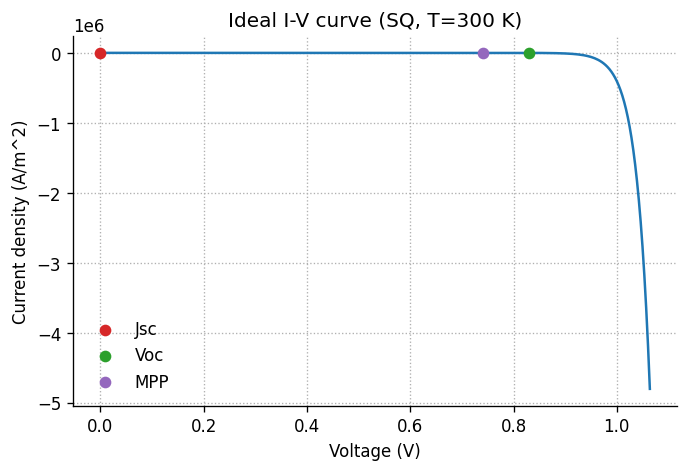

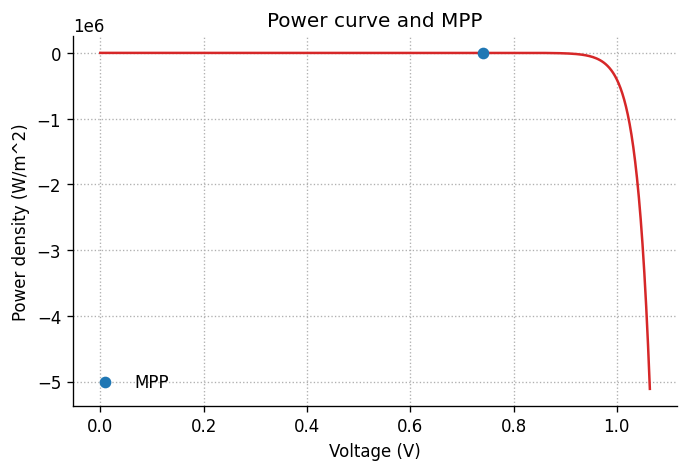

SQ summary
Metric         | Value
---------------+------
Jsc (A/m^2)    | 553.1
Voc (V)        | 0.830
Efficiency (%) | 30.11
MPP V (V)      | 0.740
MPP J (A/m^2)  | 535.6



In [9]:
sq = shockley_queisser_limit(result.gap_ev, cell_temperature_k=temperature_k)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(sq.voltages, sq.currents, color="#1f77b4")
ax.scatter([0.0], [sq.j_sc], color="#d62728", zorder=5, label="Jsc")
ax.scatter([sq.v_oc], [0.0], color="#2ca02c", zorder=5, label="Voc")
ax.scatter([sq.v_mpp], [sq.j_mpp], color="#9467bd", zorder=5, label="MPP")
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current density (A/m^2)")
ax.set_title(f"Ideal I-V curve (SQ, T={temperature_k:.0f} K)")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_sq_iv_curve.png")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(sq.voltages, sq.power, color="#d62728")
ax.scatter([sq.v_mpp], [sq.v_mpp * sq.j_mpp], color="#1f77b4", zorder=5, label="MPP")
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Power density (W/m^2)")
ax.set_title("Power curve and MPP")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_sq_power_curve.png")

print_table(
    ["Metric", "Value"],
    [
        ("Jsc (A/m^2)", f"{sq.j_sc:.1f}"),
        ("Voc (V)", f"{sq.v_oc:.3f}"),
        ("Efficiency (%)", f"{sq.efficiency*100:.2f}"),
        ("MPP V (V)", f"{sq.v_mpp:.3f}"),
        ("MPP J (A/m^2)", f"{sq.j_mpp:.1f}"),
    ],
    title="SQ summary",
)


## Step-junction diode: temperature and I-V behavior
We now compute temperature-dependent band gap, carrier statistics, built-in potential, depletion widths, and the Shockley I-V curve for a silicon step junction. This section uses non-degenerate statistics and temperature-dependent mobility.


In [10]:
si = silicon()

n_side = DopantCase(label="P (n-side)", n_cm3=DIODE["n_side_cm3"], p_cm3=0.0)
p_side = DopantCase(label="B (p-side)", n_cm3=0.0, p_cm3=DIODE["p_side_cm3"])

t_min, t_max, t_steps = DIODE["temperature_range_k"]
temperatures = np.linspace(t_min, t_max, int(t_steps))
marker_t = DIODE["marker_t_k"]

lifetime_n_s = DIODE["lifetimes_s"]["n"]
lifetime_p_s = DIODE["lifetimes_s"]["p"]


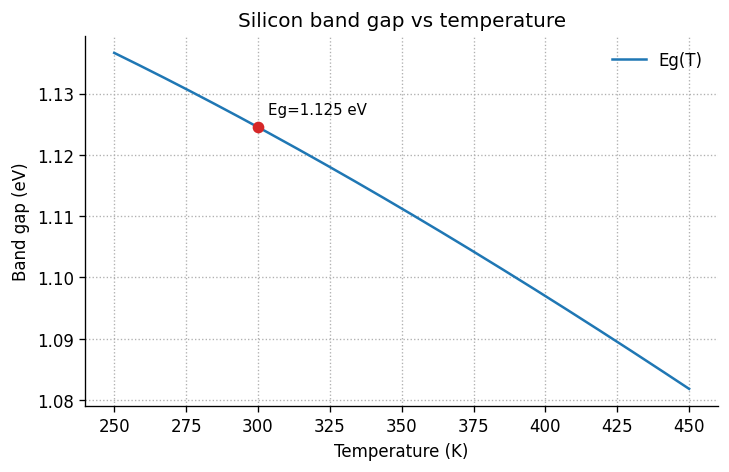

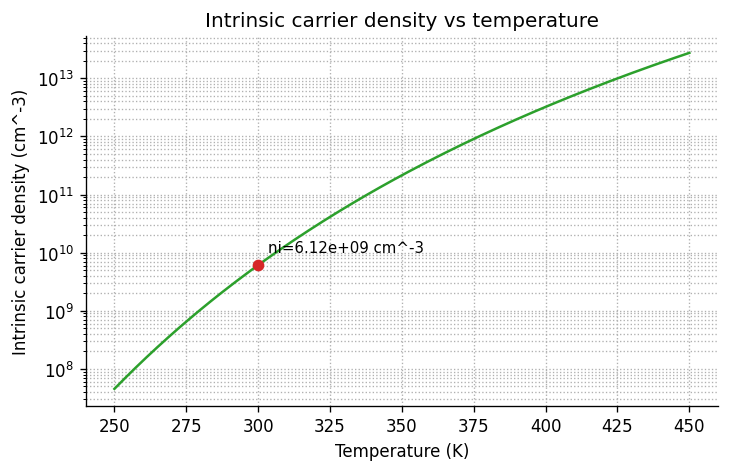

In [11]:
eg_t = varshni_gap_ev(
    temperatures,
    si.eg0_ev,
    si.varshni_alpha_ev_per_k,
    si.varshni_beta_k,
)

nc_t = effective_density_of_states_cm3(si.nc300_cm3, temperatures)

nv_t = effective_density_of_states_cm3(si.nv300_cm3, temperatures)

ni_t = intrinsic_concentration_cm3(eg_t, nc_t, nv_t, temperatures)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(temperatures, eg_t, color="#1f77b4", label="Eg(T)")

eg_300 = varshni_gap_ev(
    marker_t,
    si.eg0_ev,
    si.varshni_alpha_ev_per_k,
    si.varshni_beta_k,
)
ax.scatter([marker_t], [eg_300], color="#d62728", zorder=5)
ax.annotate(
    f"Eg={eg_300:.3f} eV",
    xy=(marker_t, eg_300),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Silicon band gap vs temperature")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_band_gap_vs_temperature.png")

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.semilogy(temperatures, ni_t, color="#2ca02c")
ni_300 = intrinsic_concentration_cm3(
    eg_300,
    effective_density_of_states_cm3(si.nc300_cm3, marker_t),
    effective_density_of_states_cm3(si.nv300_cm3, marker_t),
    marker_t,
)
ax.scatter([marker_t], [ni_300], color="#d62728", zorder=5)
ax.annotate(
    f"ni={ni_300:.2e} cm^-3",
    xy=(marker_t, ni_300),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Intrinsic carrier density (cm^-3)")
ax.set_title("Intrinsic carrier density vs temperature")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
plt.show()
save_fig(fig, results_dir / "si_intrinsic_carriers_vs_temperature.png")


Fermi levels:   0%|          | 0/161 [00:00<?, ?temp/s]

Fermi levels: 100%|██████████| 161/161 [00:00<00:00, 227062.19temp/s]

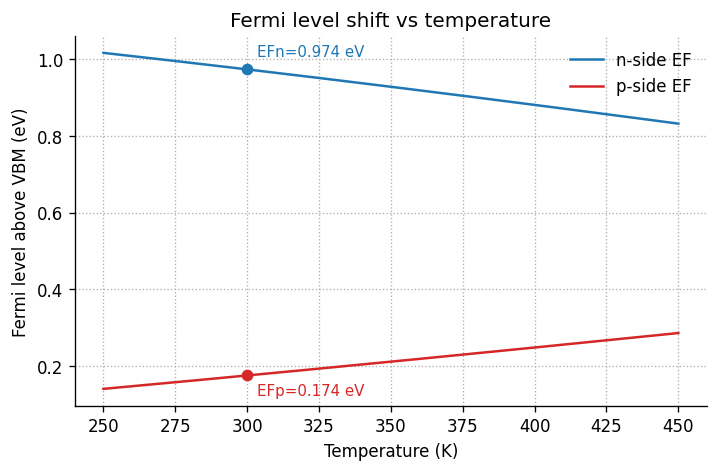

In [12]:
fermi_n = []
fermi_p = []
for t, eg, ni in tqdm(zip(temperatures, eg_t, ni_t), total=len(temperatures), desc="Fermi levels", unit="temp"):
    fermi_n.append(
        fermi_level_nondegenerate_ev(
            eg,
            t,
            n_side.n_cm3,
            n_side.p_cm3,
            ni,
        )
    )
    fermi_p.append(
        fermi_level_nondegenerate_ev(
            eg,
            t,
            p_side.n_cm3,
            p_side.p_cm3,
            ni,
        )
    )
fermi_n = np.array(fermi_n)
fermi_p = np.array(fermi_p)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(temperatures, fermi_n, color="#1f77b4", label="n-side EF")
ax.plot(temperatures, fermi_p, color="#d62728", label="p-side EF")

idx_300 = int(np.argmin(np.abs(temperatures - marker_t)))
ax.scatter([marker_t], [fermi_n[idx_300]], color="#1f77b4", zorder=5)
ax.scatter([marker_t], [fermi_p[idx_300]], color="#d62728", zorder=5)
ax.annotate(
    f"EFn={fermi_n[idx_300]:.3f} eV",
    xy=(marker_t, fermi_n[idx_300]),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
    color="#1f77b4",
)
ax.annotate(
    f"EFp={fermi_p[idx_300]:.3f} eV",
    xy=(marker_t, fermi_p[idx_300]),
    xytext=(6, -12),
    textcoords="offset points",
    fontsize=9,
    color="#d62728",
)

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Fermi level above VBM (eV)")
ax.set_title("Fermi level shift vs temperature")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_fermi_level_vs_temperature.png")


Junction widths:   0%|          | 0/161 [00:00<?, ?temp/s]

Junction widths: 100%|██████████| 161/161 [00:00<00:00, 179262.79temp/s]

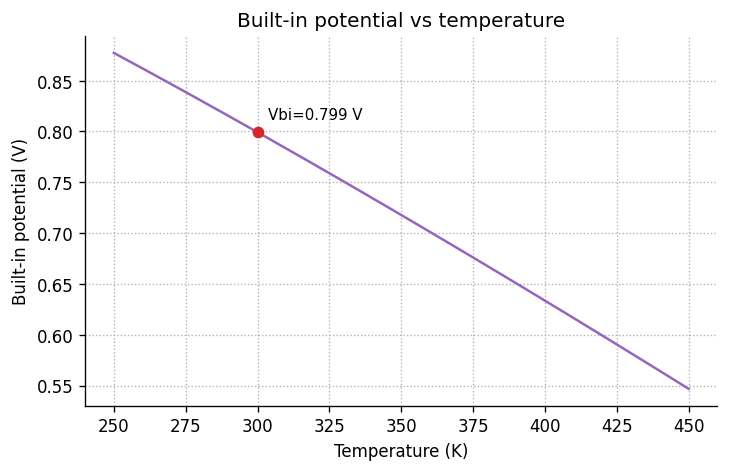

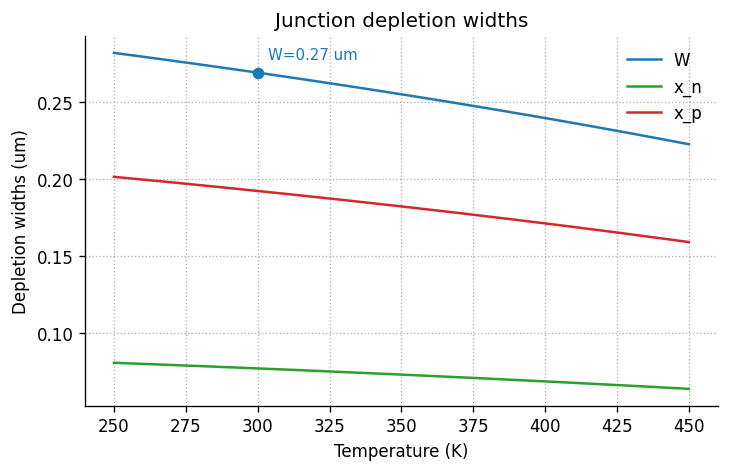

Junction summary
Metric          | Value
----------------+------
Vbi @ 300K (V)  | 0.799
W @ 300K (um)   | 0.27 
x_n @ 300K (um) | 0.08 
x_p @ 300K (um) | 0.19 



In [13]:
v_bi = []
widths = []
widths_n = []
widths_p = []
for t, ni in tqdm(zip(temperatures, ni_t), total=len(temperatures), desc="Junction widths", unit="temp"):
    v_bi.append(
        built_in_potential_v(t, n_side.n_cm3, p_side.p_cm3, ni)
    )
    w, x_n, x_p = depletion_width_cm(t, n_side.n_cm3, p_side.p_cm3, ni)
    widths.append(w)
    widths_n.append(x_n)
    widths_p.append(x_p)

v_bi = np.array(v_bi)
widths = np.array(widths)
widths_n = np.array(widths_n)
widths_p = np.array(widths_p)

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(temperatures, v_bi, color="#9467bd")
ax.scatter([marker_t], [v_bi[idx_300]], color="#d62728", zorder=5)
ax.annotate(
    f"Vbi={v_bi[idx_300]:.3f} V",
    xy=(marker_t, v_bi[idx_300]),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Built-in potential (V)")
ax.set_title("Built-in potential vs temperature")
ax.grid(True, linestyle=":", linewidth=0.8)
plt.show()
save_fig(fig, results_dir / "si_built_in_potential_vs_temperature.png")

fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(temperatures, widths * 1e4, color="#1f77b4", label="W")
ax.plot(temperatures, widths_n * 1e4, color="#2ca02c", label="x_n")
ax.plot(temperatures, widths_p * 1e4, color="#d62728", label="x_p")
ax.scatter([marker_t], [widths[idx_300] * 1e4], color="#1f77b4", zorder=5)
ax.annotate(
    f"W={widths[idx_300]*1e4:.2f} um",
    xy=(marker_t, widths[idx_300] * 1e4),
    xytext=(6, 8),
    textcoords="offset points",
    fontsize=9,
    color="#1f77b4",
)
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Depletion widths (um)")
ax.set_title("Junction depletion widths")
ax.grid(True, linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_depletion_widths_vs_temperature.png")

print_table(
    ["Metric", "Value"],
    [
        ("Vbi @ 300K (V)", f"{v_bi[idx_300]:.3f}"),
        ("W @ 300K (um)", f"{widths[idx_300] * 1e4:.2f}"),
        ("x_n @ 300K (um)", f"{widths_n[idx_300] * 1e4:.2f}"),
        ("x_p @ 300K (um)", f"{widths_p[idx_300] * 1e4:.2f}"),
    ],
    title="Junction summary",
)


Diode IV:   0%|          | 0/3 [00:00<?, ?temp/s]

Diode IV: 100%|██████████| 3/3 [00:00<00:00, 1196.55temp/s]

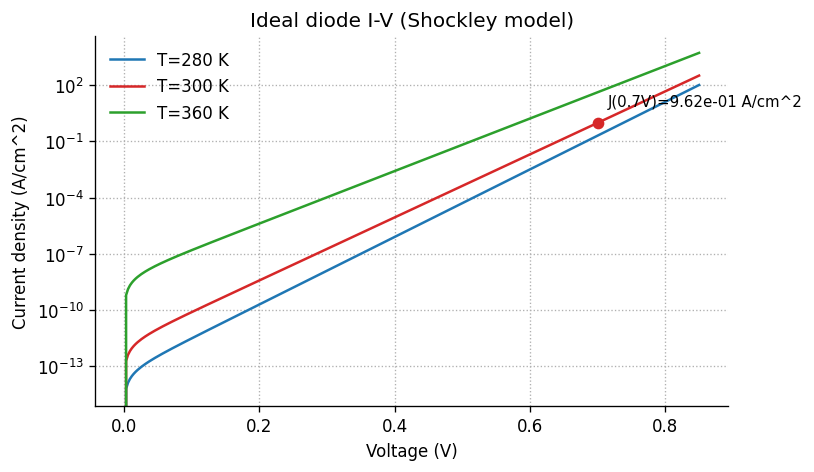

In [14]:
voltages = DIODE["voltages_v"]
plot_temps = DIODE["iv_plot_temps_k"]
colors = ["#1f77b4", "#d62728", "#2ca02c"]

fig, ax = plt.subplots(figsize=(6.8, 4))
for t, color in tqdm(zip(plot_temps, colors), total=len(plot_temps), desc="Diode IV", unit="temp"):
    eg = varshni_gap_ev(
        t,
        si.eg0_ev,
        si.varshni_alpha_ev_per_k,
        si.varshni_beta_k,
    )
    nc = effective_density_of_states_cm3(si.nc300_cm3, t)
    nv = effective_density_of_states_cm3(si.nv300_cm3, t)
    ni = intrinsic_concentration_cm3(eg, nc, nv, t)

    mu_n = mobility_power_law(si.mu_n_300_cm2_v_s, t)
    mu_p = mobility_power_law(si.mu_p_300_cm2_v_s, t)
    d_n = mu_n * thermal_voltage_v(t)
    d_p = mu_p * thermal_voltage_v(t)
    l_n = np.sqrt(d_n * lifetime_n_s)
    l_p = np.sqrt(d_p * lifetime_p_s)

    j0 = diode_saturation_current_density_a_per_cm2(
        ni,
        d_n,
        d_p,
        l_n,
        l_p,
        n_side.n_cm3,
        p_side.p_cm3,
    )

    j_v = shockley_diode_current_density_a_per_cm2(voltages, t, j0, ideality=1.0)
    ax.semilogy(voltages, j_v, color=color, label=f"T={t:.0f} K")

    if abs(t - marker_t) < 1.0:
        v_mark = 0.7
        j_mark = shockley_diode_current_density_a_per_cm2(
            np.array([v_mark]),
            t,
            j0,
        )[0]
        ax.scatter([v_mark], [j_mark], color=color, zorder=5)
        ax.annotate(
            f"J(0.7V)={j_mark:.2e} A/cm^2",
            xy=(v_mark, j_mark),
            xytext=(6, 10),
            textcoords="offset points",
            fontsize=9,
        )

ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Current density (A/cm^2)")
ax.set_title("Ideal diode I-V (Shockley model)")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend(frameon=False)
plt.show()
save_fig(fig, results_dir / "si_diode_iv_vs_temperature.png")

np.savez(
    results_dir / "si_epm_diode_results.npz",
    epm_gap=result.gap_ev,
    epm_vbm=result.vbm_ev,
    epm_cbm=result.cbm_ev,
    fermi_level=ef,
    sq_efficiency=sq.efficiency,
    vbi_300=v_bi[idx_300],
    depletion_w_300=widths[idx_300],
)
